In [1]:
import matplotlib.pyplot as plt
from astropy.io import fits
import numpy as np

In [2]:
fits_files = [
    "M13_0001.fits",
    "M13_0002.fits",
    "M13_0003.fits",
    "M13_0004.fits",
    "M13_0005.fits"
]

data_list = []

for file in fits_files:
    with fits.open(file) as hdul:
        data = hdul[0].data
        data_list.append(data)

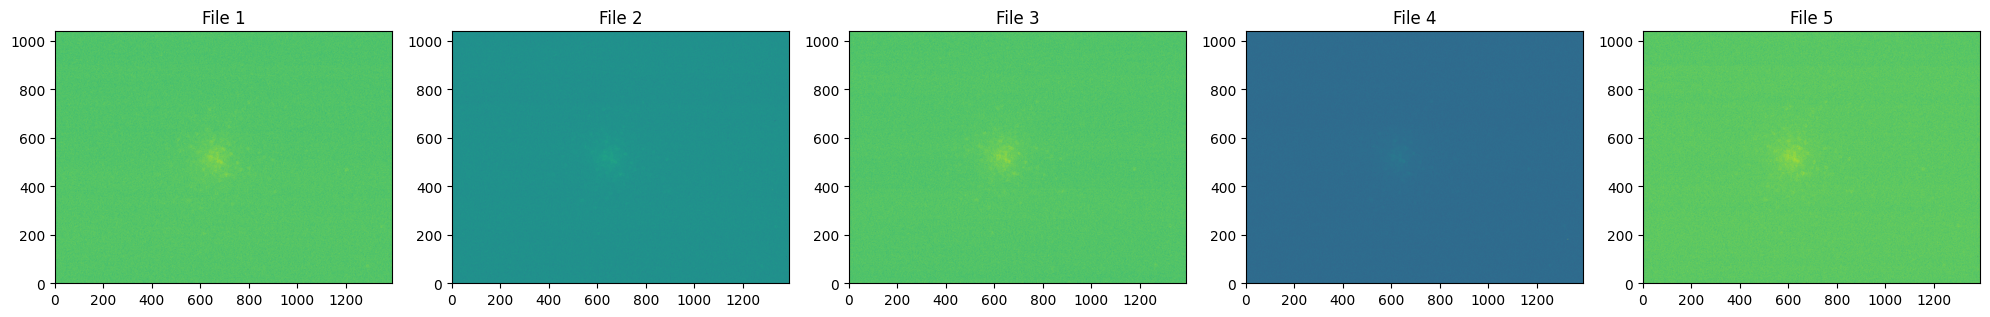

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    ax.imshow(data_list[i], origin="lower")
    ax.set_title(f"File {i+1}")

plt.tight_layout()
plt.show()

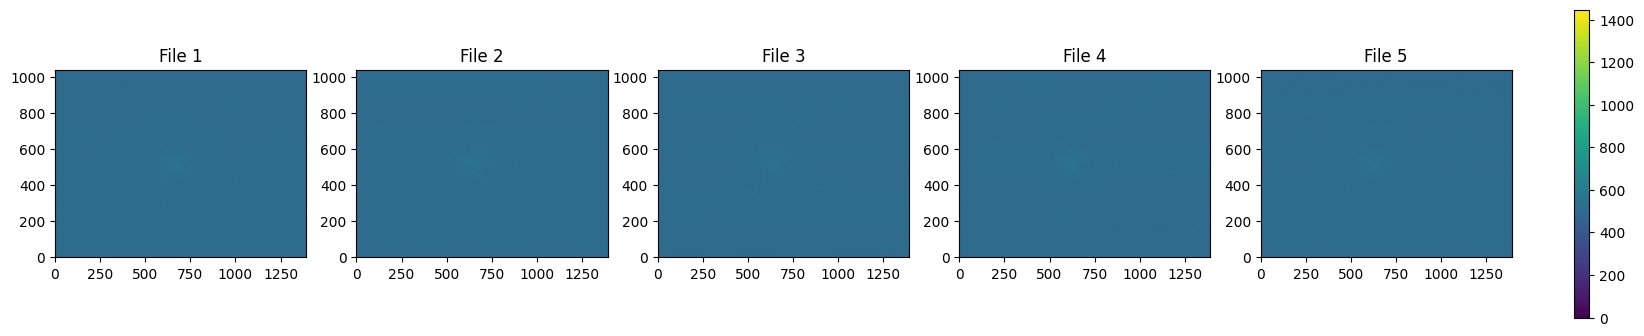

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

all_data = np.concatenate([d.flatten() for d in data_list])
vmin, vmax = np.min(all_data), np.max(all_data)

for i, ax in enumerate(axes):
    im = ax.imshow(data_list[i], origin="lower", vmin=vmin, vmax=vmax)
    ax.set_title(f"File {i+1}")

fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)

plt.show()

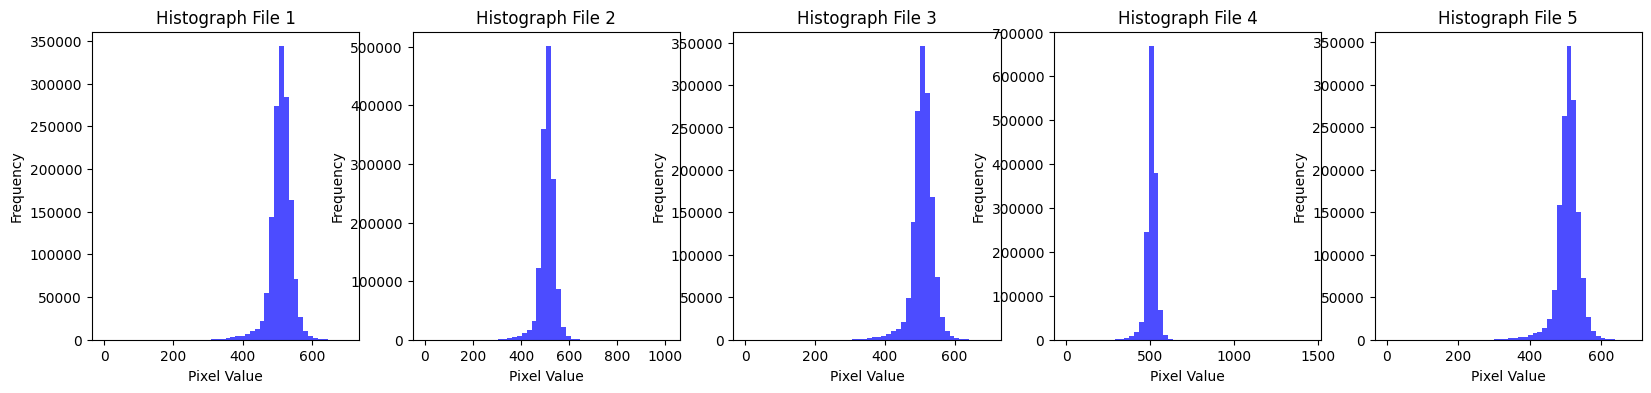

In [8]:
fig, axes = plt.subplots(1, 5, figsize = (20, 4))

for i, ax in enumerate(axes):
    ax.hist(data_list[i].ravel(), bins=50, color='blue', alpha=0.7)
    ax.set_title(f"Histograph File {i+1}")
    ax.set_xlabel("Pixel Value")
    ax.set_ylabel("Frequency")

plt.show()

The x-axis represents the pixel value, the numerical values stored in the FITS image data array. The y-axis represents the frequency or count of the pixels within a specific range on the x-axis. 

bins=50 specifies that the entire range of pixel values will be divided into 50 equally sized intervals.

most of the data is centered around 400.

the majority of the data is tightly clustered around the central peaks, the peak is narrow which indicates that background pixels have values similar to each other.

In [9]:
all_data = np.array(data_list)
combined_image = np.median(all_data, axis=0)

print(f"New median pixel intensity value: {np.median(combined_image)}")

New median pixel intensity value: 510.0


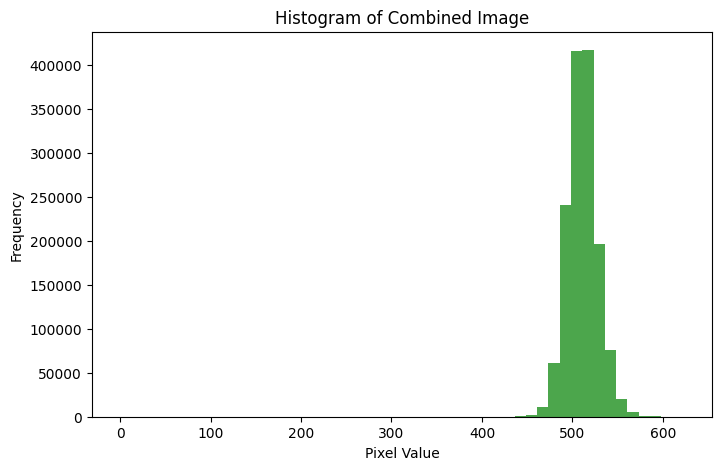

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(combined_image.ravel(), bins=50, color='green', alpha=0.7)
plt.title("Histogram of Combined Image")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

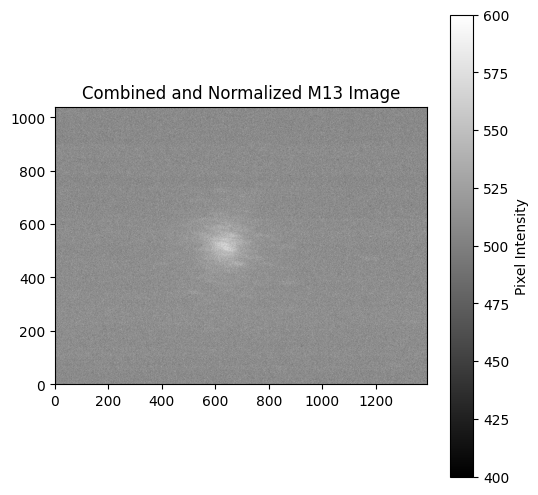

In [13]:
vmin_value = 400
vmax_value = 600

plt.figure(figsize=(6, 6))
plt.imshow(combined_image, cmap='gray', origin='lower',
           vmin=vmin_value, vmax=vmax_value)
plt.colorbar(label='Pixel Intensity')
plt.title("Combined and Normalized M13 Image")
plt.show()

In [14]:
fits.writeto("combined.fits", combined_image, overwrite=True)